## DSWRF downscale
03/27/2025 update

In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import math as m

from insolation import insolf # main package for terrain

import pygrib # NOT required
from netCDF4 import Dataset
from osgeo import gdal, osr

import random

In [2]:
# helper functions
import dswrf_func as swo

In [4]:
# PATHS
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
# HRRR_DATA = UVU_OLSON_HOME + 'HRRR/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

In [5]:
# TERRAIN
with Dataset(ERW_TOPO_FILE) as dem:
    d = dem['dem'][:].astype(np.float64)
    vf = dem['sky_view_factor'][:].astype(np.float64)

# REDUNDANCY?
# for clearsky model (x_res)
topo = gdal.Open(ERW_TOPO_FILE, gdal.GA_ReadOnly)
topo1 = gdal.Open(topo.GetSubDatasets()[0][0])
dem = topo1.GetRasterBand(1).ReadAsArray() # convert elevation to type for topocalc
dem2 = dem.astype(np.double)
geotransform = topo1.GetGeoTransform()
x_resolution = geotransform[1] # for resolution

In [6]:
dem

array([[3576.6982, 3589.3613, 3599.5254, ..., 3706.1777, 3714.5654,
        3718.1611],
       [3606.2314, 3619.9102, 3635.7139, ..., 3697.919 , 3706.2686,
        3710.4648],
       [3642.2637, 3665.5771, 3695.791 , ..., 3686.6514, 3695.5586,
        3700.6475],
       ...,
       [3075.3398, 3055.165 , 3040.0723, ..., 2723.9023, 2744.7295,
        2759.0889],
       [3071.4863, 3058.8115, 3056.8164, ..., 2713.3555, 2733.0537,
        2745.6309],
       [3092.045 , 3089.3418, 3094.331 , ..., 2700.457 , 2712.831 ,
        2728.8184]], dtype=float32)

In [7]:
# MOMENT SOL - SINGLE Day
year, month, day = [2022, 3, 1]
zenith, solar_vector, jdrng = swo.solar_positions(year, month, day)
zenith

array([147.54096669, 141.5684267 , 132.47070479, 121.78397813,
       110.36344769,  98.69368123,  87.11426046,  75.94869351,
        65.60158841,  56.65963435,  49.97741151,  46.59510927,
        47.25037391,  51.78557741,  59.2901117 ,  68.75135049,
        79.40315868,  90.72688999, 102.35233703, 113.9589909 ,
       125.1734805 , 135.41718307, 143.64238784, 148.10099163])

In [8]:
# CHECK VARS
# not required
import pygrib

# Open the GRIB file
hrrr_file = f"{HRRR_DATA}hrrr.20220301/hrrr.t16z.wrfsfcf06.grib2"
grbs = pygrib.open(hrrr_file)

# Print all available messages (metadata) in the GRIB file
for grb in grbs:
    print(grb)

# elevation_grb = grbs.select(name="Orography")[0]  # Select first matching 'Geopotential height'
# dswrf_grb = grbs.select(name="Downward short-wave radiation flux")[0]  # Select first matching 'Downward short-wave radiation flux'
# grbs.close()
# elevation_grb

1:Orography:m (instant):lambert:surface:level 0:fcst time 6 hrs:from 202203011600
2:2 metre temperature:K (instant):lambert:heightAboveGround:level 2 m:fcst time 6 hrs:from 202203011600
3:2 metre relative humidity:% (instant):lambert:heightAboveGround:level 2 m:fcst time 6 hrs:from 202203011600
4:10 metre U wind component:m s**-1 (instant):lambert:heightAboveGround:level 10 m:fcst time 6 hrs:from 202203011600
5:10 metre V wind component:m s**-1 (instant):lambert:heightAboveGround:level 10 m:fcst time 6 hrs:from 202203011600
6:Total Precipitation:kg m**-2 (accum):lambert:surface:level 0:fcst time 0-6 hrs (accum):from 202203011600
7:Total Precipitation:kg m**-2 (accum):lambert:surface:level 0:fcst time 5-6 hrs (accum):from 202203011600
8:Total Cloud Cover:% (instant):lambert:boundaryLayerCloudLayer:level 0:fcst time 6 hrs:from 202203011600
9:Total Cloud Cover:% (instant):lambert:atmosphere:level 0 -:fcst time 6 hrs:from 202203011600
10:Downward short-wave radiation flux:W m**-2 (instant)

In [9]:
# run clearsky
hour = 9
dlxy = x_resolution
Idir_hour, Idiff_hour, I_tot = swo.clearsky_insolation_inc(dem, vf, hour, jdrng, zenith, solar_vector, dlxy)
Idir_hour

array([[  0.        ,   0.        ,   0.        , ..., 510.15993083,
        560.28169832, 560.33666267],
       [  0.        ,   0.        ,   0.        , ..., 510.04493089,
        560.15488538, 560.21908896],
       [  0.        ,   0.        ,   0.        , ..., 531.90603434,
        572.54526882, 572.62476641],
       ...,
       [807.27874372, 745.15723234, 674.03814325, ..., 304.43143282,
        372.16143389, 372.3196692 ],
       [649.93762156, 467.75731122, 272.61265566, ..., 378.48262854,
        473.46631301, 473.64259714],
       [265.98061591,  89.49842774,  85.1469462 , ..., 474.05666442,
        509.50193278, 509.74375283]])

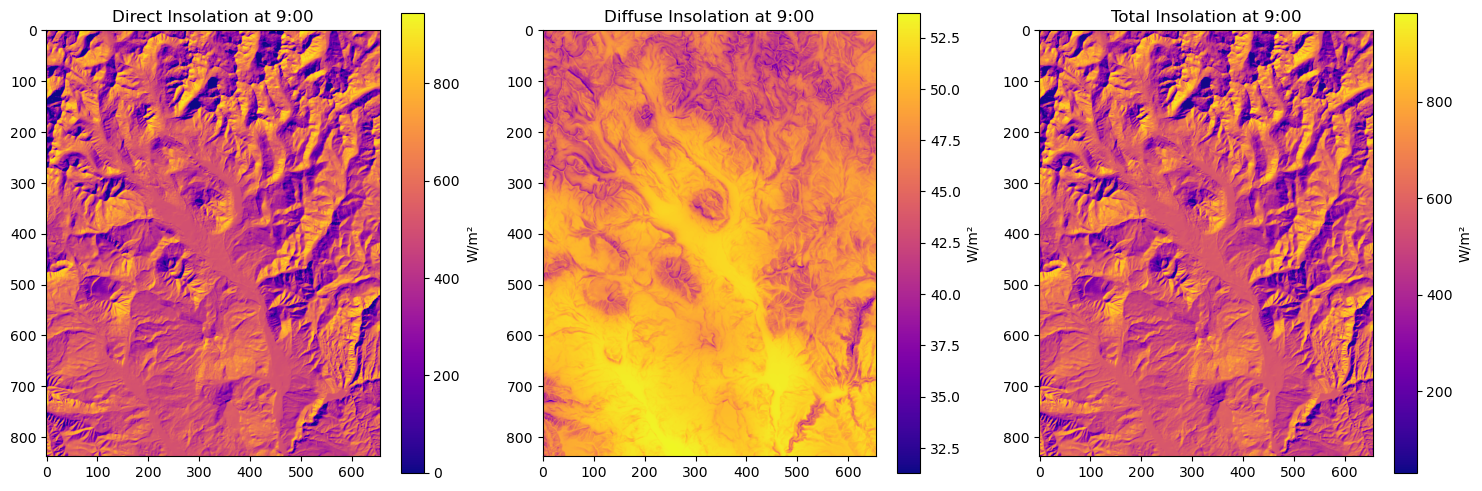

In [13]:
# Plotting the results for 9 AM (or any other hour you want)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(Idir_hour, cmap='plasma')
ax[0].set_title(f"Direct Insolation at {hour}:00")
fig.colorbar(ax[0].imshow(Idir_hour, cmap='plasma'), ax=ax[0], label="W/m²")

ax[1].imshow(Idiff_hour, cmap='plasma')
ax[1].set_title(f"Diffuse Insolation at {hour}:00")
fig.colorbar(ax[1].imshow(Idiff_hour, cmap='plasma'), ax=ax[1], label="W/m²")

ax[2].imshow(I_tot, cmap='plasma')
ax[2].set_title(f"Total Insolation at {hour}:00")
fig.colorbar(ax[2].imshow(I_tot, cmap='plasma'), ax=ax[2], label="W/m²")

plt.tight_layout()
plt.show()

In [14]:
#### BETTER CLEARSKY MODEL

In [15]:
# Read and warp HRRR file for same day
time_utc = 18 # 15 is 9AM?
if(time_utc-6 < 10):
    time_utcf = "0"+str(time_utc-6)
else:
    time_utcf = time_utc - 6 # adjust for forecast hour

print(f"utc hour {time_utc} or f6 {time_utcf}")
topo_nc_path=ERW_TOPO_FILE
hrrr_file = f"{HRRR_DATA}hrrr.20220301/hrrr.t{time_utcf}z.wrfsfcf06.grib2"
hrrr_warp = swo.hrrr_warp_domain(hrrr_file, topo_nc_path, resample_option="cubic")

utc hour 18 or f6 12


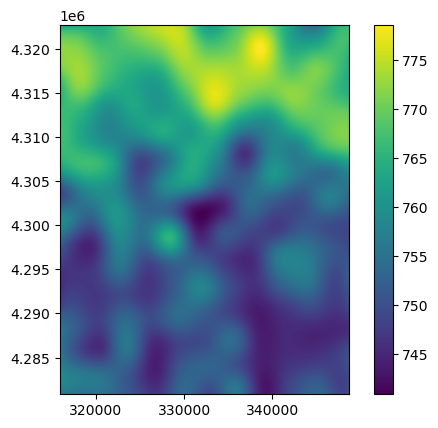

In [16]:
# Plot warped HRRR
band_hrrr = hrrr_warp.GetRasterBand(10) # 10th variable is sw
data_hrrr = band_hrrr.ReadAsArray()
# geotransform information
geotransform = hrrr_warp.GetGeoTransform()

# matplotlib
plt.figure()
plt.imshow(data_hrrr, cmap='viridis', extent=[geotransform[0], geotransform[0] + geotransform[1] * hrrr_warp.RasterXSize,
                                      geotransform[3] + geotransform[5] * hrrr_warp.RasterYSize, geotransform[3]])
plt.colorbar()
plt.show()

In [17]:
# SW correction
# DNI - normal: sw arriving perpendicular to sun's rays (uncorrected)
# GHI - horizontal: arriving on a horizontal surface
#   ***HRRR is  GHI and therefore must be slope corrected - issues with DIF assumptions

## DSWRF
GHI = DNI*cosZ + DIF

## for VIS
GHI_vis = DNI_vis * cosZ + DIF_vis

## visible diffuse fraction (k)
K_vis = DIF_vis / GIS_vis

# separation of global broadband
DIF = GHI * K_vis
DNI = (GHI - DIF) / cosZ



# US

GHI = DNI / cosZ # divide both
K = bean_vis/dif_vis
DNI = DBI * (1-k) *cozZ + DIF # direct goes back

NameError: name 'DNI' is not defined

In [18]:
dswrf = hrrr_warp.GetRasterBand(10).ReadAsArray()
GHI = dswrf / np.cos(zenith[hour]*m.pi/180) # local zenith

In [19]:
# FUNCTION FOR TOPO CORRECTIONS
shd = insolf.doshade(np.array(dem), dlxy, solar_vector[:, hour])
zen_hr = zenith[hour]
cos_i = insolf.hillshading(dem, dlxy, solar_vector[:, hour])

## OPTION
# diffuse fraction options (k)
k2Lm = swo.diffusef_Lk2_boulder(GHI, zen_hr, I0=1367)
k_standard = 0.2
k_vis = hrrr_warp.GetRasterBand(11).ReadAsArray() / hrrr_warp.GetRasterBand(12).ReadAsArray()

# choice
k = k_vis

# split

GHI = hrrr_warp.GetRasterBand(10).ReadAsArray() / np.cos(zenith[hour]*m.pi/180) # incorrect

DIR = GHI * (1-k) * shd * cos_i
DIF = GHI * k * (1-vf) #* np.cos(zen_hr*m.pi/180)
dswrf2 = DIR+DIF

In [23]:
# INITIAL TRY (wrong)

GHI = hrrr_warp.GetRasterBand(10).ReadAsArray()

DIF = GHI * k
DNI = (GHI - DIF)/np.cos(zenith[hour]*m.pi/180) * shd * cos_i
DIF = DIF * (1-vf) #* np.cos(zen_hr*m.pi/180)
TOT = DNI + DIF

In [24]:
# JOES EQ (wrong)
dswrf = hrrr_warp.GetRasterBand(10).ReadAsArray()
DNI = (dswrf / (np.cos(zenith[hour]*m.pi/180) + k)) * shd * cos_i
DIF = (GHI * k) * vf
TOT = DNI + DIF

In [20]:
# FINAL EQUATION
GHI = hrrr_warp.GetRasterBand(10).ReadAsArray()
DNI = ((GHI * (1-k)) / (np.cos(zenith[hour]*m.pi/180))) * shd * cos_i
DIF = (DNI * k) * vf
TOT = DNI + DIF

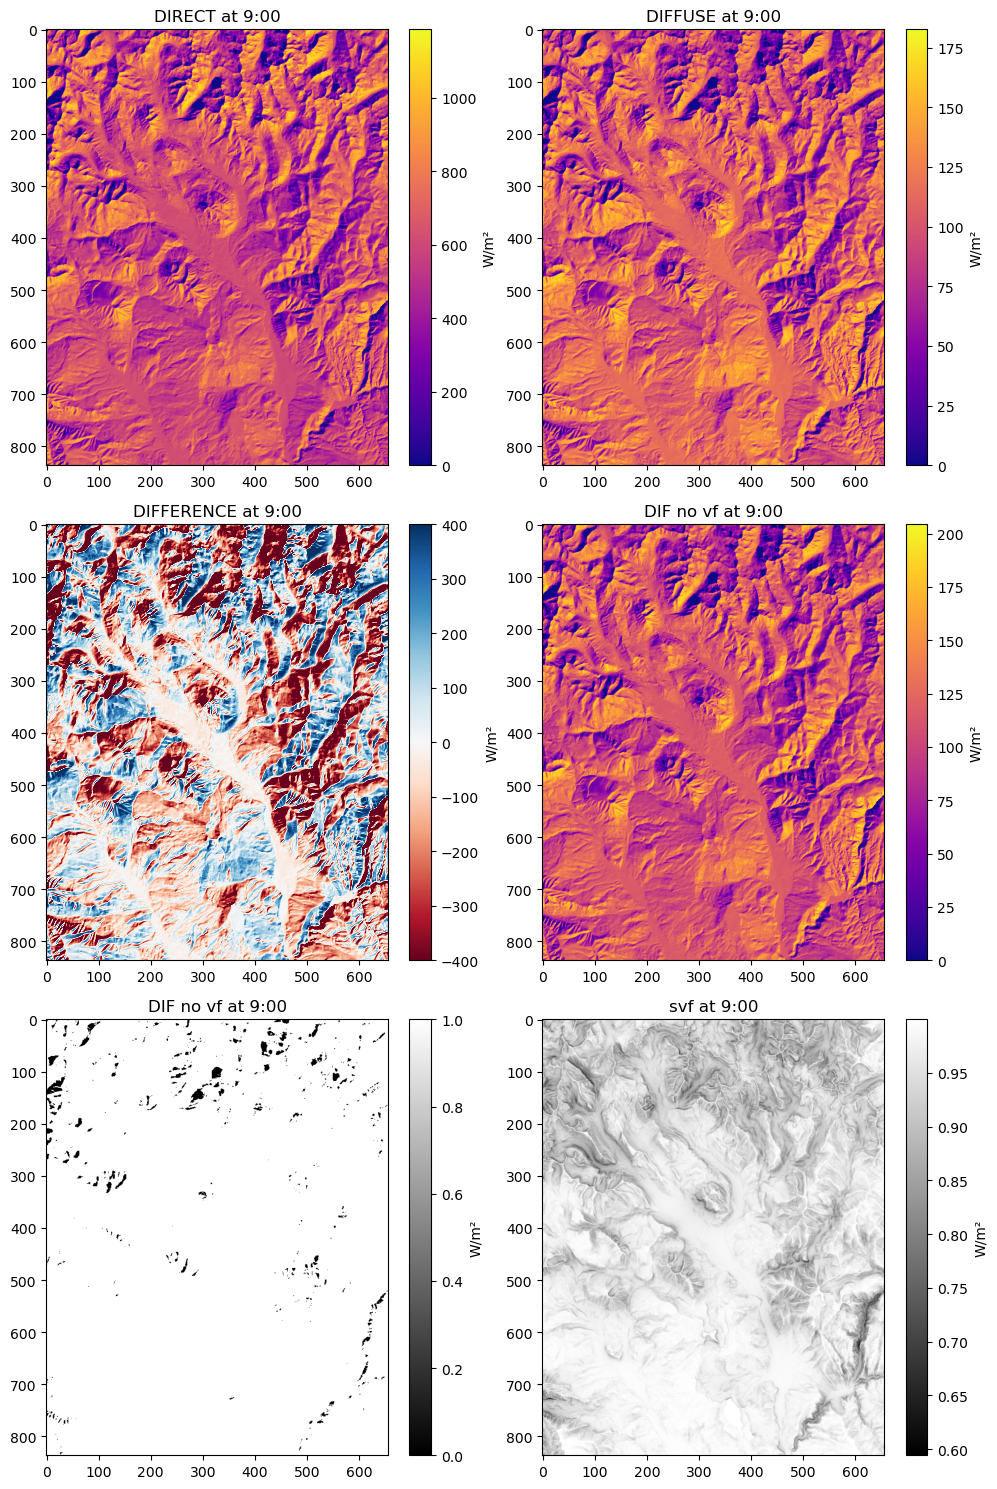

In [21]:
fig, ax = plt.subplots(3, 2, figsize=(10, 15))
ax = ax.ravel()
data = ax[0].imshow(DNI, cmap='plasma')
ax[0].set_title(f"DIRECT at {hour}:00")
fig.colorbar(data, ax=ax[0], label="W/m²")

data = ax[1].imshow(DIF, cmap='plasma')
ax[1].set_title(f"DIFFUSE at {hour}:00")
fig.colorbar(data, ax=ax[1], label="W/m²")

data = ax[2].imshow(TOT - dswrf, cmap='RdBu', vmin=-400, vmax=400)
ax[2].set_title(f"DIFFERENCE at {hour}:00")
fig.colorbar(data, ax=ax[2], label="W/m²")

data = ax[3].imshow((DNI * k), cmap='plasma')
ax[3].set_title(f"DIF no vf at {hour}:00")
fig.colorbar(data, ax=ax[3], label="W/m²")

data = ax[4].imshow(shd, cmap='grey')
ax[4].set_title(f"DIF no vf at {hour}:00")
fig.colorbar(data, ax=ax[4], label="W/m²")

data = ax[5].imshow(vf, cmap='grey')
ax[5].set_title(f"svf at {hour}:00")
fig.colorbar(data, ax=ax[5], label="W/m²")


plt.tight_layout()
plt.show()

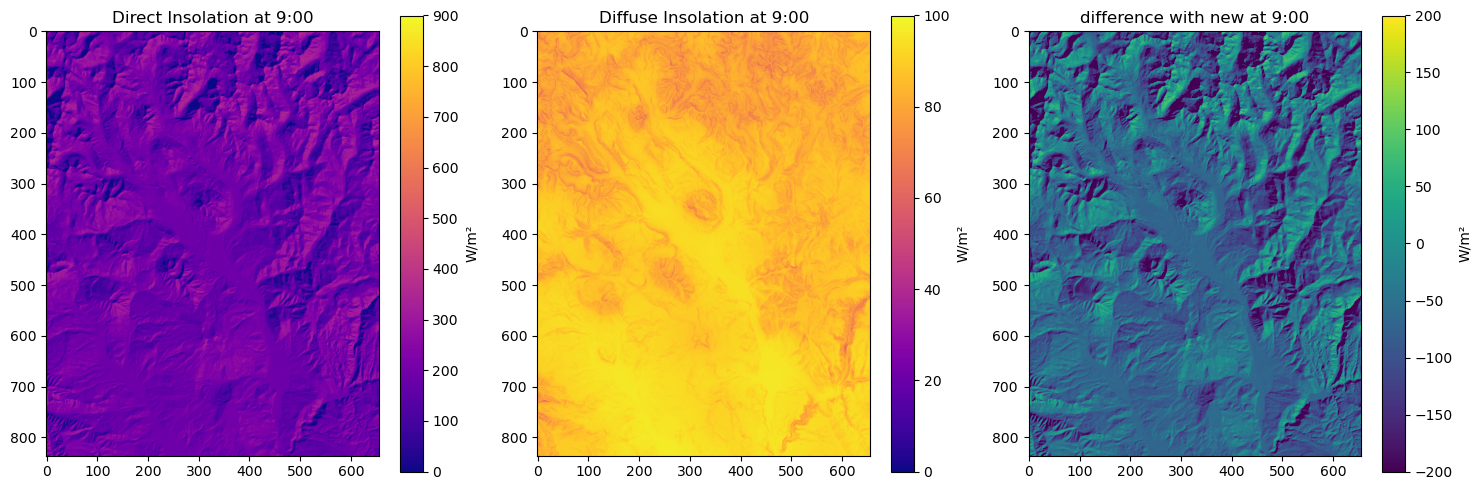

In [103]:
# Plot New

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(DIR, cmap='plasma', vmin = 0, vmax=900)
ax[0].set_title(f"Direct Insolation at {hour}:00")
fig.colorbar(ax[0].imshow(hrrr_dir, cmap='plasma', vmin = 0, vmax=900), ax=ax[0], label="W/m²")

ax[1].imshow(DIF, cmap='plasma', vmin = 0, vmax=100)
ax[1].set_title(f"Diffuse Insolation at {hour}:00")
fig.colorbar(ax[1].imshow(Idiff_hour, cmap='plasma', vmin = 0, vmax=100), ax=ax[1], label="W/m²")

ax[2].imshow(TOT - GHI, cmap='plasma', vmin = -200, vmax=200)
ax[2].set_title(f"difference with new at {hour}:00")
fig.colorbar(ax[2].imshow(TOT - GHI, cmap='viridis', vmin = -200, vmax=200), ax=ax[2], label="W/m²")

plt.tight_layout()
plt.show()

In [ ]:
# Plotting the split results from HRRR down
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(Idir_hour, cmap='plasma')
ax[0].set_title(f"Direct Insolation at {hour}:00")
fig.colorbar(ax[0].imshow(Idir_hour, cmap='plasma'), ax=ax[0], label="W/m²")

ax[1].imshow(Idiff_hour, cmap='plasma')
ax[1].set_title(f"Diffuse Insolation at {hour}:00")
fig.colorbar(ax[1].imshow(Idiff_hour, cmap='plasma'), ax=ax[1], label="W/m²")

ax[2].imshow(I_tot, cmap='plasma')
ax[2].set_title(f"Total Insolation at {hour}:00")
fig.colorbar(ax[2].imshow(I_tot, cmap='plasma'), ax=ax[2], label="W/m²")

plt.tight_layout()
plt.show()

In [ ]:
## HRRR

# simple vars
gpm = hrrr_warp.GetRasterBand(1).ReadAsArray() # Elelvation
temp = hrrr_warp.GetRasterBand(2).ReadAsArray() # Temperature C
rh = hrrr_warp.GetRasterBand(3).ReadAsArray() # RH %
dsw = hrrr_warp.GetRasterBand(10).ReadAsArray() #



# Plot raster data and store the returned image object
fig, axs = plt.subplots(2, 3, figsize=(15, 5))

# Inputs
# Downscale HRRR
# CALCULATE CLEARSKY w/ rh and temp
Idir_hour, Idiff_hour, I_tot = calculate_insolation2(dem2, zenith, hour, x_resolution, RH=rh.astype(np.double),
                                                   tempK= (temp.astype(np.double) + 273.15) )




## for GISPLIT
# sza: the solar zenith angle, in degrees
# eth: the extraterrestrial solar irradiance, in W/m2
# ghi: the global horizontal irradiance, in W/m2
# ghics: the clear-sky global horizontal irradiance, in W/m2
# difcs: the clear-sky diffuse irradiance, in W/m2
sza = np.full_like(dsw, zenith[hour])
eth = np.full_like(dsw, 1367)
ghi = dsw/m.cos(zenith[hour]) # shape = (837, 656)
ghics = Idir_hour
difcs = Idiff_hour

df = gridded_data_to_dataframe(sza, eth, ghi, ghics, difcs)

# GISPLIT  *****
k = 0.2

# split
hrrr_dir = ghi * (1-k)
hrrr_dif = ghi * k

# resample


# downsample
hrrr_dif = hrrr_dir_cubic * vf * zen_hr
hrrr_dir = hrrr_dif_cubic * sh * hsh

im1 = axs[0, 0].imshow(gpm, cmap='terrain')  # elevation
axs[0, 0].set_title('DEM')
im2 = axs[0, 1].imshow(temp, cmap='plasma')  # temperature
axs[0, 1].set_title('Temp')
im3 = axs[0, 2].imshow(rh, cmap='Blues')  # relative humidity
axs[0, 2].set_title('RH')


im4 = axs[1, 0].imshow(Idir_hour, cmap='plasma')
axs[1, 0].set_title(f"Clear-sky Insolation at {hour}:00")

im5 = axs[1, 1].imshow(Idiff_hour, cmap='plasma')
axs[1, 1].set_title(f"Clear-sky Insolation at {hour}:00")

im6 = axs[1, 2].imshow(I_tot, cmap='plasma')
axs[1, 2].set_title(f"Clear-sky Insolation at {hour}:00")




# Add colorbars
fig.colorbar(im1, ax=axs[0, 0]) 
fig.colorbar(im2, ax=axs[0, 1]) 
fig.colorbar(im3, ax=axs[0, 2]) 
fig.colorbar(im4, ax=axs[1, 0]) 
fig.colorbar(im5, ax=axs[1, 1]) 
fig.colorbar(im6, ax=axs[1, 2]) 

plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()
